In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# ══════════════════════════════════════════════════════
# NETWORK VİSUALİZATION — AĞ NE ÖĞRENDİ?
# ══════════════════════════════════════════════════════
#
# Şimdiye kadar hep sayılarla çalıştık
# Ama ağın içinde ne oluyor?
# Filtreler ne öğrendi?
# Hangi pikseller kararı etkiliyor?
#
# Bu bölümde 3 teknik öğreneceğiz:
#
# 1. Filter Visualization
#    CNN'in öğrendiği filtreleri görselleştir
#    İlk katman filtreleri anlaşılabilir
#
# 2. Saliency Maps
#    "Hangi piksel bu kararı etkiledi?"
#    Gradient'e bak → büyük gradient = önemli piksel
#
# 3. Class Visualization
#    "Kedi görüntüsü nasıl görünmeli?"
#    Gradient ascent ile görüntü üret
# ══════════════════════════════════════════════════════

print("Q4 Network Visualization başlıyor!")

Q4 Network Visualization başlıyor!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


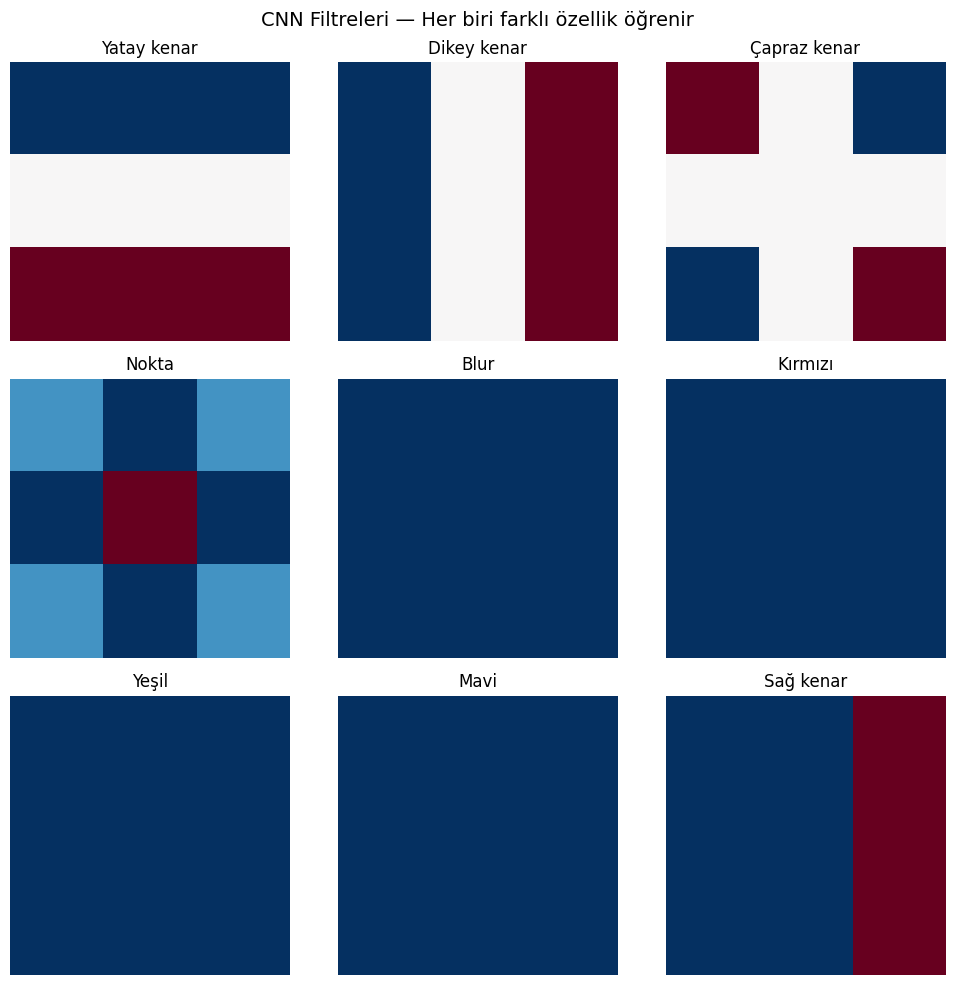

Gerçek CNN'lerde bu filtreler eğitimle otomatik öğrenilir!


In [3]:
# ══════════════════════════════════════════════════════
# 1. FİLTER VİSUALİZATION
# ══════════════════════════════════════════════════════
#
# CNN'in ilk katmanındaki filtreleri görselleştir
# İlk katman filtreleri anlaşılabilir şeyler öğrenir:
#   - Kenarlar (yatay, dikey, çapraz)
#   - Renkler
#   - Dokular
#
# Derin katmanlar daha soyut → görselleştirmek zor
# ══════════════════════════════════════════════════════

np.random.seed(42)

# Rastgele filtreler oluştur (gerçekte eğitimle öğrenilir)
# Gerçek CNN filtreleri genellikle şuna benzer:
# Kenar dedektörleri, renk dedektörleri vs.

# 16 tane 3x3x3 filtre (3 kanallı RGB görüntü için)
filtreler = np.random.randn(16, 3, 3, 3)

# Normalize et — görselleştirme için
def normalize_filtre(f):
    f = f - f.min()
    f = f / (f.max() + 1e-8)
    return f

# Elle tanımlanmış anlamlı filtreler
anlamli_filtreler = np.zeros((9, 3, 3, 3))

# Yatay kenar — tüm kanallarda
anlamli_filtreler[0, :] = [[-1,-1,-1],[0,0,0],[1,1,1]]
# Dikey kenar
anlamli_filtreler[1, :] = [[-1,0,1],[-1,0,1],[-1,0,1]]
# Çapraz kenar
anlamli_filtreler[2, :] = [[1,0,-1],[0,0,0],[-1,0,1]]
# Nokta dedektörü
anlamli_filtreler[3, :] = [[0,-1,0],[-1,4,-1],[0,-1,0]]
# Yumuşatma (blur)
anlamli_filtreler[4, :] = [[1,1,1],[1,1,1],[1,1,1]]
# Kırmızı kanal dedektörü
anlamli_filtreler[5, 0] = [[1,1,1],[1,1,1],[1,1,1]]
# Yeşil kanal
anlamli_filtreler[6, 1] = [[1,1,1],[1,1,1],[1,1,1]]
# Mavi kanal
anlamli_filtreler[7, 2] = [[1,1,1],[1,1,1],[1,1,1]]
# Sağ kenar
anlamli_filtreler[8, :] = [[0,0,1],[0,0,1],[0,0,1]]

isimler = ['Yatay kenar', 'Dikey kenar', 'Çapraz kenar',
           'Nokta', 'Blur', 'Kırmızı', 'Yeşil', 'Mavi', 'Sağ kenar']

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    # Filtreyi (3,3,3) → (3,3) ortalamasına al
    f = anlamli_filtreler[i].mean(axis=0)
    f = normalize_filtre(f)
    ax.imshow(f, cmap='RdBu_r')
    ax.set_title(isimler[i])
    ax.axis('off')

plt.suptitle("CNN Filtreleri — Her biri farklı özellik öğrenir", fontsize=14)
plt.tight_layout()
plt.show()

print("Gerçek CNN'lerde bu filtreler eğitimle otomatik öğrenilir!")

Görüntü:
[[0.  0.  0.  0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0. ]
 [0.  0.  1.  1.  1.  1.  0.  0. ]
 [0.  0.  1.  0.5 0.5 1.  0.  0. ]
 [0.  0.  1.  0.5 0.5 1.  0.  0. ]
 [0.  0.  1.  1.  1.  1.  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0. ]]


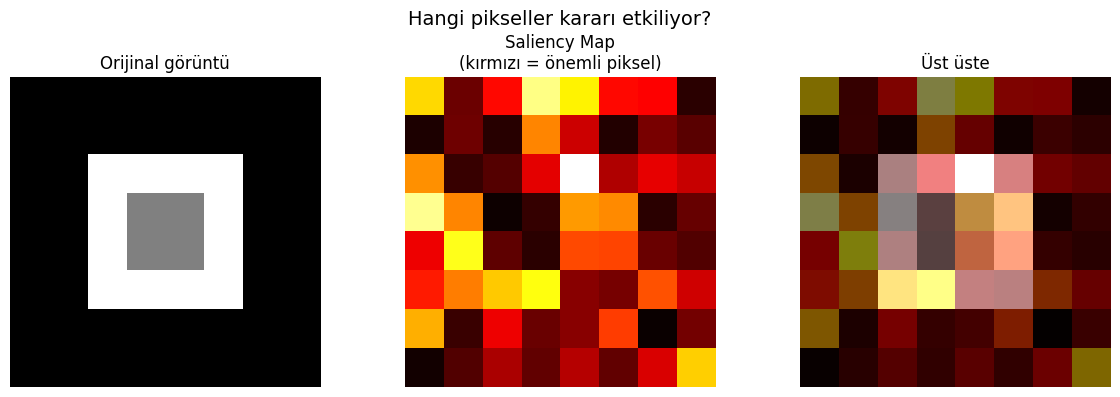


Gerçek CNN'de:
Kedi görüntüsü → kulaklar, gözler parlak çıkar
Arka plan karanlık kalır


In [4]:
# ══════════════════════════════════════════════════════
# 2. SALİENCY MAP — HANGİ PİKSEL ÖNEMLİ?
# ══════════════════════════════════════════════════════
#
# Soru: "Bu görüntüyü kedi olarak sınıflandırırken
#        hangi pikseller kararı etkiledi?"
#
# Yöntem: Gradient'e bak!
#   dLoss/dX → her pikselin loss'a etkisi
#   Büyük gradient → o piksel çok önemli!
#
# Assignment 1'de W için gradient hesapladık
# Burada X (görüntü) için gradient hesaplıyoruz
# ══════════════════════════════════════════════════════

np.random.seed(0)

# Basit görüntü — 8x8, 1 kanal
# Ortada bir şekil var
goruntu = np.zeros((8, 8))
goruntu[2:6, 2:6] = 1.0   # ortada kare
goruntu[3:5, 3:5] = 0.5   # içinde daha açık

print("Görüntü:")
print(goruntu)

# Basit model — sadece toplam piksel değeri kullan
# (gerçekte CNN kullanılır)
def basit_model(x, dogru_sinif=0):
    # Skor = piksel değerlerinin ağırlıklı toplamı
    W = np.random.randn(*x.shape)
    skor = np.sum(x * W)
    return skor, W

skor, W = basit_model(goruntu)

# Gradient = W (bu basit modelde)
# Gerçek CNN'de backprop ile hesaplanır
saliency = np.abs(W)  # mutlak değer — yön değil büyüklük önemli
saliency = saliency / saliency.max()  # normalize

# Görselleştir
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(goruntu, cmap='gray')
axes[0].set_title("Orijinal görüntü")
axes[0].axis('off')

axes[1].imshow(saliency, cmap='hot')
axes[1].set_title("Saliency Map\n(kırmızı = önemli piksel)")
axes[1].axis('off')

# Üst üste göster
axes[2].imshow(goruntu, cmap='gray')
axes[2].imshow(saliency, cmap='hot', alpha=0.5)
axes[2].set_title("Üst üste")
axes[2].axis('off')

plt.suptitle("Hangi pikseller kararı etkiliyor?", fontsize=14)
plt.tight_layout()
plt.show()

print("\nGerçek CNN'de:")
print("Kedi görüntüsü → kulaklar, gözler parlak çıkar")
print("Arka plan karanlık kalır")

Başlangıç görüntüsü: [0.00761038 0.00121675 0.00443863 0.00333674]
Başlangıç kedi skoru: 0.0217

Final görüntüsü: [ 8.82787211 11.20568275  4.75488072  2.05632925]
Final kedi skoru: 46.0454


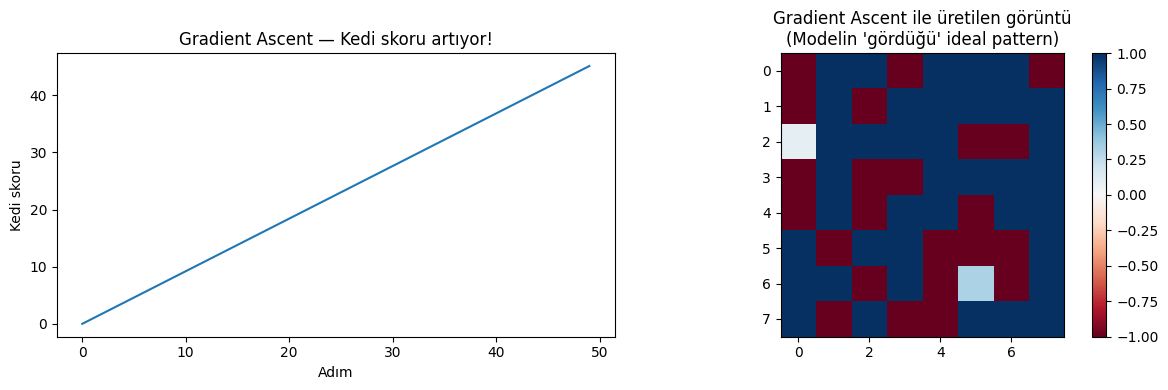


Gerçek CNN'de bu teknik:
'Mükemmel kedi' → kulaklar, bıyıklar, gözler belirginleşir
'Mükemmel araba' → tekerlekler, karoseri belirginleşir


In [5]:
# ══════════════════════════════════════════════════════
# 3. CLASS VİSUALİZATION — "KEDİ GÖRÜNTÜSÜ NASIL GÖRÜNMELI?"
# ══════════════════════════════════════════════════════
#
# Soru: "Modele göre mükemmel kedi görüntüsü nasıl olur?"
#
# Yöntem: Gradient Ascent
#   Normal eğitimde: W'yu güncelle, X sabit
#   Burada: X'i güncelle, W sabit!
#
#   1. Rastgele görüntüden başla
#   2. "Kedi skoru" için gradient hesapla
#   3. Gradient yönünde görüntüyü güncelle
#   4. Tekrarla → kedi skoru maksimum olana kadar
# ══════════════════════════════════════════════════════

np.random.seed(0)

# Basit model — 4 piksel → 3 sınıf
W_model = np.random.randn(4, 3)  # (piksel, sınıf)

def model_skoru(x, W):
    return x @ W  # shape (3,) — 3 sınıf skoru

# Hedef sınıf: 0 (kedi)
hedef_sinif = 0
lr = 0.1
adim_sayisi = 50

# Rastgele görüntüden başla
x = np.random.randn(4) * 0.01
print(f"Başlangıç görüntüsü: {x}")
print(f"Başlangıç kedi skoru: {model_skoru(x, W_model)[hedef_sinif]:.4f}")

skorlar_gecmisi = []

for adim in range(adim_sayisi):
    # Kedi skorunu hesapla
    skor = model_skoru(x, W_model)[hedef_sinif]
    skorlar_gecmisi.append(skor)

    # Gradient: skoru arttırmak için X'i hangi yönde değiştirmeliyiz?
    grad = W_model[:, hedef_sinif]  # dSkor/dX

    # Gradient ASCENT — skoru maksimize et
    x = x + lr * grad

# Sonuç
print(f"\nFinal görüntüsü: {x}")
print(f"Final kedi skoru: {model_skoru(x, W_model)[hedef_sinif]:.4f}")

# Grafik
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(skorlar_gecmisi)
plt.xlabel("Adım")
plt.ylabel("Kedi skoru")
plt.title("Gradient Ascent — Kedi skoru artıyor!")

plt.subplot(1, 2, 2)
x_gorsel = np.random.randn(8, 8) * 0.01
W_gorsel = np.random.randn(64, 1)

for _ in range(100):
    grad = W_gorsel[:, 0]
    x_gorsel = x_gorsel + 0.1 * grad.reshape(8, 8)
    x_gorsel = np.clip(x_gorsel, -1, 1)

plt.imshow(x_gorsel, cmap='RdBu')
plt.title("Gradient Ascent ile üretilen görüntü\n(Modelin 'gördüğü' ideal pattern)")
plt.colorbar()

plt.tight_layout()
plt.show()

print("\nGerçek CNN'de bu teknik:")
print("'Mükemmel kedi' → kulaklar, bıyıklar, gözler belirginleşir")
print("'Mükemmel araba' → tekerlekler, karoseri belirginleşir")

In [6]:
# ══════════════════════════════════════════════════════
# NETWORK VİSUALİZATION ÖZET
# ══════════════════════════════════════════════════════

print("╔══════════════════════════════════════════════════╗")
print("║        NETWORK VİSUALİZATION ÖZET                ║")
print("╠══════════════════════════════════════════════════╣")
print("║                                                  ║")
print("║  1. Filter Visualization                         ║")
print("║     CNN filtreleri görselleştir                  ║")
print("║     İlk katman → kenarlar, renkler               ║")
print("║     Derin katman → yüzler, nesneler              ║")
print("║                                                  ║")
print("║  2. Saliency Map                                 ║")
print("║     dLoss/dX → hangi piksel önemli?              ║")
print("║     Büyük gradient = önemli piksel               ║")
print("║     Kedi → kulaklar, gözler önemli               ║")
print("║                                                  ║")
print("║  3. Class Visualization                          ║")
print("║     Gradient Ascent ile görüntü üret             ║")
print("║     X sabit değil, W sabit!                      ║")
print("║     'Modele göre mükemmel kedi nasıl görünür?'   ║")
print("║                                                  ║")
print("║  Neden önemli?                                   ║")
print("║     Modelin ne öğrendiğini anlıyoruz             ║")
print("║     Hataları tespit edebiliyoruz                 ║")
print("║     'Kara kutu' olmaktan çıkıyor                 ║")
print("╚══════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════╗
║        NETWORK VİSUALİZATION ÖZET                ║
╠══════════════════════════════════════════════════╣
║                                                  ║
║  1. Filter Visualization                         ║
║     CNN filtreleri görselleştir                  ║
║     İlk katman → kenarlar, renkler               ║
║     Derin katman → yüzler, nesneler              ║
║                                                  ║
║  2. Saliency Map                                 ║
║     dLoss/dX → hangi piksel önemli?              ║
║     Büyük gradient = önemli piksel               ║
║     Kedi → kulaklar, gözler önemli               ║
║                                                  ║
║  3. Class Visualization                          ║
║     Gradient Ascent ile görüntü üret             ║
║     X sabit değil, W sabit!                      ║
║     'Modele göre mükemmel kedi nasıl görünür?'   ║
║                                             